# Clase 6: Introducción a Python
## El consumidor racional como hilo conductor

Ya sabes R. Python no es tan diferente — los conceptos son los mismos, la sintaxis cambia un poco. En esta clase aprendemos Python construyendo algo que ya conoces de teoría microeconómica: el problema del consumidor.

Un consumidor tiene:
- Una **cesta de bienes** (qué consume)
- Una **función de utilidad** (cuánto le satisface cada cesta)
- Una **restricción presupuestaria** (cuánto puede gastar)
- Un **problema de optimización** (maximizar utilidad sujeto al presupuesto)

Vamos a representar todo eso en Python.

---
## 1. Python vs R: las diferencias clave

Antes de empezar, tres diferencias que te van a sorprender si vienes de R:

| | R | Python |
|---|---|---|
| Asignación | `x <- 5` | `x = 5` |
| Índices | Empiezan en **1** | Empiezan en **0** |
| Estructura | Todo es vector | Hay varios tipos de colecciones |
| Imprimir | `print(x)` o solo `x` | `print(x)` o solo `x` en Jupyter |

El índice desde 0 es el que más confunde al principio. En R, el primer elemento es `x[1]`. En Python es `x[0]`.

---
## 2. Tipos de datos básicos

Los mismos que en R, con nombres ligeramente distintos.

In [1]:
# Numérico
precio_tacos   = 25.0    # float — números con decimales
precio_refresco = 15     # int — números enteros

# Texto
nombre_bien = "tacos"

# Booleano (True/False — con mayúscula, a diferencia de R)
es_bien_normal = True

# type() equivale a class() en R
print(type(precio_tacos))
print(type(precio_refresco))
print(type(nombre_bien))
print(type(es_bien_normal))

<class 'float'>
<class 'int'>
<class 'str'>
<class 'bool'>


In [2]:
# Operaciones básicas — igual que R
ingreso    = 200
precio_x   = 25
precio_y   = 15

# ¿Cuántos tacos puedo comprar si gasto todo en tacos?
max_tacos = ingreso / precio_x
print(f"Máximo de tacos: {max_tacos}")

# El f"..." es un f-string — permite meter variables dentro de texto
# equivale a paste0() en R
print(f"Con ingreso {ingreso} y precio {precio_x}, compro hasta {max_tacos:.1f} tacos")

Máximo de tacos: 8.0
Con ingreso 200 y precio 25, compro hasta 8.0 tacos


In [15]:
# ¿Qué pasa con el máximo de tacos si el precio sube?
# En vez de calcularlo a mano para cada precio, usamos un for loop

precios_posibles = [15, 20, 25, 30, 40]   # lista de precios a explorar

for precio in precios_posibles:
    maximo = ingreso / precio
    print(f"Si px = {precio}, puedo comprar hasta {maximo:.1f} tacos")

Si px = 15, puedo comprar hasta 13.3 tacos
Si px = 20, puedo comprar hasta 10.0 tacos
Si px = 25, puedo comprar hasta 8.0 tacos
Si px = 30, puedo comprar hasta 6.7 tacos
Si px = 40, puedo comprar hasta 5.0 tacos


In [16]:
# El loop también puede tener condiciones adentro
# ¿En qué precios puedo comprar más de 6 tacos?

print("Precios donde puedo comprar más de 6 tacos:")

for precio in precios_posibles:
    maximo = ingreso / precio
    if maximo > 6:
        print(f"  px = {precio} → {maximo:.1f} tacos ✓")
    else:
        print(f"  px = {precio} → {maximo:.1f} tacos ✗")

Precios donde puedo comprar más de 6 tacos:
  px = 15 → 13.3 tacos ✓
  px = 20 → 10.0 tacos ✓
  px = 25 → 8.0 tacos ✓
  px = 30 → 6.7 tacos ✓
  px = 40 → 5.0 tacos ✗


---
## 3. Listas — la cesta de bienes

Una lista en Python es una secuencia ordenada de elementos. Puede mezclar tipos. Es el equivalente más cercano al vector de R, pero más flexible.

In [3]:
# La cesta de bienes del consumidor
# [cantidad de tacos, cantidad de refrescos]
cesta = [4, 3]

# Indexación — EMPIEZA EN 0, no en 1
print(f"Tacos: {cesta[0]}")
print(f"Refrescos: {cesta[1]}")

# Modificar un elemento
cesta[0] = 6
print(f"Nueva cesta: {cesta}")

# Longitud de la lista
print(f"Número de bienes: {len(cesta)}")   # len() equivale a length() en R

Tacos: 4
Refrescos: 3
Nueva cesta: [6, 3]
Número de bienes: 2


In [4]:
# Las listas pueden contener cualquier tipo — incluso otras listas
bienes = ["tacos", "refrescos", "churros"]
precios = [25, 15, 10]
cantidades = [4, 3, 2]

# Operaciones sobre listas con comprensiones
# Esto es el equivalente de la vectorización de R
# En R: gasto <- precios * cantidades
# En Python NO puedes multiplicar listas directamente — necesitas una comprensión

gasto = [p * q for p, q in zip(precios, cantidades)]
#              zip() une dos listas elemento por elemento
#          para cada par (p, q), calculamos p * q

print(f"Gasto por bien: {gasto}")
print(f"Gasto total: {sum(gasto)}")

Gasto por bien: [100, 45, 20]
Gasto total: 165


### List comprehensions

La sintaxis `[expresión for elemento in iterable]` es una de las cosas más características de Python. Lee igual que en matemáticas:

$$\{p_i \cdot q_i \mid i \in \text{bienes}\}$$

```python
[p * q for p, q in zip(precios, cantidades)]
```

En R harías `precios * cantidades` directamente porque los vectores se vectorizan automáticamente. En Python las listas no — necesitas la comprensión o NumPy (que vemos más adelante).

---
## 4. Tuplas — la cesta que no cambia

Una tupla es como una lista pero **inmutable**: una vez creada, no puedes modificarla. Se usa para cosas que no deben cambiar — como los precios que el consumidor toma como dados.

In [7]:
# Los precios son exógenos para el consumidor — no los controla
# Una tupla es la estructura correcta para representarlos
precios = (25, 15, 10)   # paréntesis en vez de corchetes

print(f"Precio de tacos: {precios[0]}")
print(f"Precio de refrescos: {precios[1]}")

# Intentar modificar una tupla da error — eso es exactamente lo que queremos
# precios[0] = 30   # descomenta esta línea para ver el error: TypeError

Precio de tacos: 25
Precio de refrescos: 15


In [8]:
# Las tuplas se pueden desempaquetar directamente
precio_tacos, precio_refresco, precio_churros = precios

print(f"Tacos: {precio_tacos}, Refrescos: {precio_refresco}, Churros: {precio_churros}")

Tacos: 25, Refrescos: 15, Churros: 10


---
## 5. Diccionarios — el mapa de bienes y características

Un diccionario guarda pares **clave: valor**. Es la estructura más útil en Python para datos con etiquetas — equivale a una named list en R.

In [9]:
# El consumidor: un diccionario con toda su información
consumidor = {
    "nombre":   "Ana",
    "ingreso":  200,
    "cesta":    {"tacos": 4, "refrescos": 3, "churros": 2},
    "precios":  {"tacos": 25, "refrescos": 15, "churros": 10}
}

# Acceder a elementos
print(f"Nombre: {consumidor['nombre']}")
print(f"Ingreso: {consumidor['ingreso']}")
print(f"Tacos en la cesta: {consumidor['cesta']['tacos']}")

Nombre: Ana
Ingreso: 200
Tacos en la cesta: 4


In [11]:
# iteramos sobre las claves del diccionario: "tacos", "refrescos", "churros"
for bien in consumidor['cesta']:
    cantidad = consumidor['cesta'][bien]
    precio   = consumidor['precios'][bien]
    print(f"{bien}: {cantidad} × {precio} = {cantidad * precio}")

tacos: 4 × 25 = 100
refrescos: 3 × 15 = 45
churros: 2 × 10 = 20


In [12]:
# sum() colapsa todo eso en un solo número — igual que sum() en R
gasto_total = sum(
    consumidor['cesta'][bien] * consumidor['precios'][bien]
    for bien in consumidor['cesta']
)

print(f"Gasto total: {gasto_total}")
print(f"Ingreso:     {consumidor['ingreso']}")

# la comparación devuelve True o False directamente
print(f"¿Factible?   {gasto_total <= consumidor['ingreso']}")

Gasto total: 165
Ingreso:     200
¿Factible?   True


In [17]:
# Agregar un bien nuevo al diccionario
consumidor['cesta']['agua'] = 1
consumidor['precios']['agua'] = 8

print(f"Cesta actualizada: {consumidor['cesta']}")

Cesta actualizada: {'tacos': 4, 'refrescos': 3, 'churros': 2, 'agua': 1}


---
## 6. Funciones — la función de utilidad

En Python las funciones se definen con `def`. La indentación (espacios al inicio de la línea) es obligatoria — no hay llaves `{}` como en otros lenguajes, el bloque de código se define por el sangrado.

In [20]:
# ── Anatomía de una función en Python ────────────────────────────────────────
#
#   def nombre_funcion(arg1, arg2, arg_opcional=valor_default):
#       """docstring: describe qué hace la función"""
#       # cuerpo — indentado obligatoriamente
#       return resultado
#
# Las diferencias con R:
#   R:      f <- function(x, y) { ... }
#   Python: def f(x, y): ...
#
# La indentación (4 espacios) delimita el cuerpo — no hay llaves {}
# return es explícito, igual que en R

# Función de utilidad Cobb-Douglas: U(x, y) = x^alpha * y^(1-alpha)
# alpha es la participación del bien 1 en el gasto óptimo

def utilidad_cobb_douglas(x, y, alpha=0.5):
    #                      ↑  ↑   ↑
    #                      |  |   argumento con valor por defecto
    #                      |  argumento obligatorio
    #                      argumento obligatorio
    """
    Calcula la utilidad Cobb-Douglas de una cesta (x, y).

    Parámetros:
        x     : cantidad del bien 1 (tacos)
        y     : cantidad del bien 2 (refrescos)
        alpha : participación del bien 1 (default = 0.5)

    Retorna:
        Nivel de utilidad (float)
    """
    # ** es el operador de potencia — equivale a ^ en R
    # alpha=0.5 si no se especifica → preferencias simétricas
    return x**alpha * y**(1 - alpha)


# Llamar la función sin especificar alpha — usa el default 0.5
u = utilidad_cobb_douglas(4, 3)
print(f"Utilidad de (4, 3) con alpha=0.5: {u:.4f}")

# Llamar la función con alpha distinto — más peso al bien 1
# los argumentos con nombre se pueden pasar en cualquier orden
u2 = utilidad_cobb_douglas(4, 3, alpha=0.7)
print(f"Utilidad de (4, 3) con alpha=0.7: {u2:.4f}")

# Verificar que alpha=0.7 da más utilidad cuando x > y
# (el consumidor valora más los tacos, y tiene más tacos que refrescos)
print(f"¿Subió la utilidad al aumentar alpha? {u2 > u}")

Utilidad de (4, 3) con alpha=0.5: 3.4641
Utilidad de (4, 3) con alpha=0.7: 3.6693
¿Subió la utilidad al aumentar alpha? True


In [21]:
# Verificar la restricción presupuestaria
def es_factible(x, y, px, py, ingreso):
    """
    Verifica si la cesta (x, y) es factible dado el presupuesto.
    Retorna True si px*x + py*y <= ingreso.
    """
    gasto = px * x + py * y
    return gasto <= ingreso, gasto   # en Python puedes retornar múltiples valores

factible, gasto = es_factible(4, 3, 25, 15, 200)
print(f"Gasto: {gasto}, Factible: {factible}")

Gasto: 145, Factible: True


---
## 7. Condicionales y loops

La lógica de control es igual a R, con la diferencia de que Python usa indentación en vez de llaves.

In [24]:
# if/elif/else — igual que if/else if/else en R
gasto = 150
ingreso = 200

if gasto > ingreso:
    print("Cesta no factible — gasta más de lo que tiene")
elif gasto == ingreso:
    print("Cesta exactamente sobre la restricción presupuestaria")
else:
    ahorro = ingreso - gasto
    print(f"Cesta factible — sobran {ahorro} pesos")

Cesta factible — sobran 50 pesos


In [25]:
# for loop — iterar sobre una lista de cestas y calcular su utilidad
cestas = [(2, 6), (4, 3), (6, 1), (8, 0)]   # lista de tuplas (x, y)

print("Cesta    | Utilidad | Factible")
print("-" * 35)

for x, y in cestas:
    u = utilidad_cobb_douglas(x, y)
    factible, gasto = es_factible(x, y, px=25, py=15, ingreso=200)
    print(f"({x}, {y})      | {u:.4f}   | {factible}  (gasto={gasto})")

Cesta    | Utilidad | Factible
-----------------------------------
(2, 6)      | 3.4641   | True  (gasto=140)
(4, 3)      | 3.4641   | True  (gasto=145)
(6, 1)      | 2.4495   | True  (gasto=165)
(8, 0)      | 0.0000   | True  (gasto=200)


---
## 8. NumPy — vectorización como en R

Las listas de Python no se vectorizan automáticamente. Para hacer operaciones numéricas eficientes usamos **NumPy** — la librería de álgebra lineal de Python. En R estás acostumbrado a `c(1,2,3) * 2` — eso en Python requiere NumPy.

In [26]:
import numpy as np   # importar NumPy con el alias np — convención universal

# np.array es el equivalente del vector de R
precios    = np.array([25, 15, 10])
cantidades = np.array([4, 3, 2])

# Ahora sí se vectoriza automáticamente
gasto = precios * cantidades
print(f"Gasto por bien: {gasto}")
print(f"Gasto total: {gasto.sum()}")
print(f"Gasto promedio por bien: {gasto.mean():.2f}")

Gasto por bien: [100  45  20]
Gasto total: 165
Gasto promedio por bien: 55.00


In [27]:
# La restricción presupuestaria como conjunto de cestas factibles
# Si el consumidor gasta todo en tacos y refrescos:
# 25*x + 15*y = 200
# y = (200 - 25*x) / 15

ingreso = 200
px, py  = 25, 15

# np.linspace genera una secuencia de valores equiespaciados
# equivale a seq() en R
x = np.linspace(0, ingreso/px, 100)   # de 0 al máximo de tacos
y = (ingreso - px * x) / py           # restricción presupuestaria

print(f"Si x=0, y máximo = {y[0]:.2f}")
print(f"Si y=0, x máximo = {x[-1]:.2f}")   # -1 es el último elemento

Si x=0, y máximo = 13.33
Si y=0, x máximo = 8.00


---
## 9. Visualización con Matplotlib

Matplotlib es el equivalente de base R graphics. No es tan elegante como ggplot2, pero es poderoso y flexible.

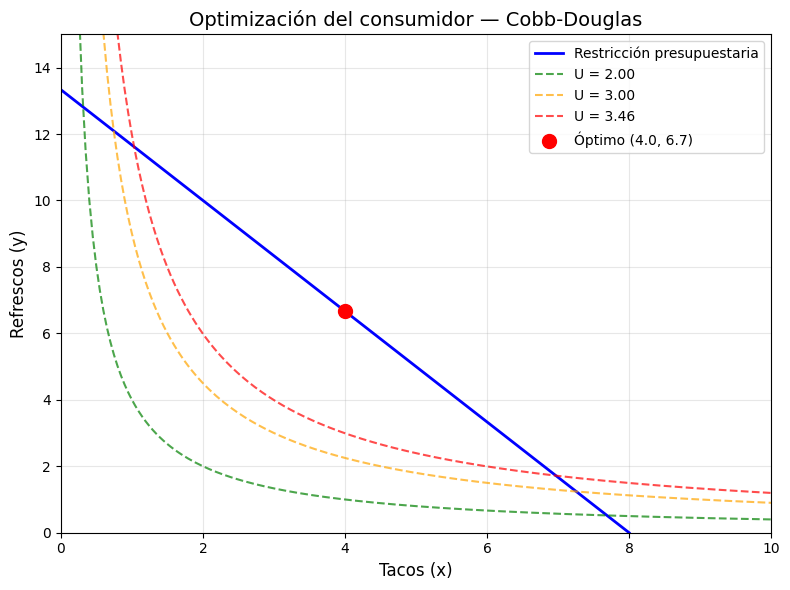

In [28]:
import matplotlib.pyplot as plt

# ── Estructura básica de una gráfica en Matplotlib ───────────────────────────
#
# En ggplot2 construyes la gráfica sumando capas con +
# En Matplotlib creas primero el "lienzo" y luego le agregas elementos
#
# fig = la figura completa (el PNG que se va a generar)
# ax  = el área donde se dibuja (los ejes, los datos)
# plt.subplots() crea ambos a la vez
# figsize=(8, 6) es el tamaño en pulgadas: ancho=8, alto=6

fig, ax = plt.subplots(figsize=(8, 6))

# ── Restricción presupuestaria ────────────────────────────────────────────────
# ax.plot(x, y) dibuja una línea conectando los puntos (x[0],y[0]), (x[1],y[1])...
# 'b-' es un shorthand de formato: 'b' = azul (blue), '-' = línea sólida
# otras opciones: 'r--' = rojo punteado, 'g.' = verde con puntos
# label= es el texto que aparece en la leyenda

ax.plot(x, y, 'b-', linewidth=2, label='Restricción presupuestaria')

# ── Curvas de indiferencia ────────────────────────────────────────────────────
# Iteramos sobre tres tuplas (nivel_utilidad, color)
# cada tupla genera una curva de indiferencia distinta
#
# Con U = x^0.5 * y^0.5, despejando y:
# U² = x * y  →  y = U² / x
# eso es lo que graficamos para cada nivel de U

for u_nivel, color in [(2, 'green'), (3, 'orange'), (3.46, 'red')]:

    # np.linspace(0.1, 10, 200): 200 puntos entre 0.1 y 10
    # empezamos en 0.1 y no en 0 para evitar división entre cero
    x_ci = np.linspace(0.1, 10, 200)
    y_ci = (u_nivel**2) / x_ci

    # linestyle='--' = línea punteada
    # alpha=0.7 = 70% opaco (30% transparente) — para que no tape la restricción
    # f'U = {u_nivel:.2f}' construye el texto de la leyenda dinámicamente
    ax.plot(x_ci, y_ci, color=color, linestyle='--', alpha=0.7,
            label=f'U = {u_nivel:.2f}')

# ── Punto óptimo ──────────────────────────────────────────────────────────────
# Con Cobb-Douglas y alpha=0.5 la solución analítica es:
# x* = alpha * I / px    y* = (1-alpha) * I / py

x_opt = 0.5 * ingreso / px   # 0.5 * 200 / 25 = 4
y_opt = 0.5 * ingreso / py   # 0.5 * 200 / 15 = 6.67

# ax.scatter dibuja puntos sueltos (no una línea)
# s=100 es el tamaño del punto
# zorder=5 controla el orden de capas — número más alto = dibujado encima
ax.scatter(x_opt, y_opt, color='red', s=100, zorder=5,
           label=f'Óptimo ({x_opt:.1f}, {y_opt:.1f})')

# ── Configuración estética ────────────────────────────────────────────────────
ax.set_xlabel('Tacos (x)', fontsize=12)      # etiqueta eje x
ax.set_ylabel('Refrescos (y)', fontsize=12)  # etiqueta eje y
ax.set_title('Optimización del consumidor — Cobb-Douglas', fontsize=14)
ax.legend(fontsize=10)    # muestra la leyenda con todos los label= que pusimos
ax.set_xlim(0, 10)        # rango del eje x
ax.set_ylim(0, 15)        # rango del eje y
ax.grid(True, alpha=0.3)  # cuadrícula semitransparente de fondo

# tight_layout() ajusta los márgenes para que nada se corte
# show() renderiza y muestra la figura — sin esto no aparece nada
plt.tight_layout()
plt.show()